# 现代卷积神经网络 

**参考**: [动手学深度学习 第7章](https://zh-v2.d2l.ai/chapter_convolutional-modern/index.html)

AlexNet、VGG、NiN、GoogLeNet 的设计思想

批量归一化（Batch Normalization）的原理与实现

 ResNet 残差连接解决梯度消失的机制
 
DenseNet 稠密连接的设计



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

# 检查设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')
print(f'PyTorch 版本: {torch.__version__}')

使用设备: cuda
PyTorch 版本: 2.8.0+cu126


In [3]:
# 辅助函数：计算模型参数量
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 辅助函数：打印每层输出形状
def print_layer_shapes(model, input_shape=(1, 1, 224, 224)):
    X = torch.randn(input_shape)
    print(f"{'层名称':<30} {'输出形状':<25}")
    print('-' * 55)
    for name, layer in model.named_children():
        X = layer(X)
        print(f'{name:<30} {str(X.shape):<25}')

# 辅助函数：快速训练一个epoch（用小数据集演示）
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

In [ ]:
# 加载 Fashion-MNIST（缩放到 96x96 以兼容各网络的最小输入要求）
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

# 为快速演示，只取子集
subset_size = 2000
train_subset = torch.utils.data.Subset(train_dataset, range(subset_size))
test_subset  = torch.utils.data.Subset(test_dataset,  range(500))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_subset,  batch_size=64, shuffle=False)

classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'训练集大小: {len(train_subset)}  测试集大小: {len(test_subset)}')

100.0%
100.0%
100.0%
100.0%

训练集大小: 2000  测试集大小: 500


---
### 6.1. AlexNet — 深度学习的里程碑 <a id='alexnet'></a>

2012 年，AlexNet 在 ImageNet 竞赛中以超越第二名 **10%** 的精度夺冠，开启了深度学习时代。


![](assets\AlexNet_Original_block_diagram.svg.png)



| 创新点 | 说明 |
|--------|------|
| **ReLU 激活** | 替代 sigmoid/tanh，缓解梯度消失，加速收敛 |
| **Dropout** | 训练时随机丢弃神经元，防止过拟合 |
| **数据增广** | 随机裁剪、翻转，增强泛化能力 |
| **GPU 并行** | 双 GPU 训练，突破内存限制 |
| **局部响应归一化 (LRN)** | 现已被 BN 取代 |

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 大卷积核，大步幅，快速降维
            nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Block 2: 更小卷积核，增大通道数
            nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Block 3-5: 连续三个 3×3 卷积
            nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 4096), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(4096, 4096),         nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

alexnet = AlexNet(num_classes=10)
print(f'AlexNet 参数量: {count_params(alexnet):,}')

# 验证前向传播形状
dummy = torch.randn(2, 1, 96, 96)
print(f'输入形状: {dummy.shape}  输出形状: {alexnet(dummy).shape}')

In [ ]:
# 训练 AlexNet（少量 epoch 演示）
alexnet = AlexNet(num_classes=10).to(device)
optimizer = optim.Adam(alexnet.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print('AlexNet 训练中...')
for epoch in range(3):
    t0 = time.time()
    train_loss, train_acc = train_epoch(alexnet, train_loader, optimizer, criterion, device)
    test_loss,  test_acc  = eval_epoch(alexnet, test_loader, criterion, device)
    print(f'Epoch {epoch+1}/3 | 训练损失={train_loss:.4f} 准确率={train_acc:.3f} '
          f'| 测试损失={test_loss:.4f} 准确率={test_acc:.3f} | 耗时={time.time()-t0:.1f}s')

---
### 6.2. VGG — 使用块的网络 <a id='vgg'></a>

VGGNet（2014，Oxford）证明了：**网络深度是影响性能的关键因素**。
- 全部使用 **3×3 卷积核**（两个 3×3 等价于一个 5×5，参数更少，非线性更强）
- 网络由多个 **VGG 块** 堆叠而成，每块末尾用 MaxPool 降维
- 结构规整，易于扩展（VGG-11/13/16/19）

**VGG 块结构**
```
VGG Block(num_convs, out_channels):
    [Conv(out_channels, 3×3, pad=1) → ReLU] × num_convs
    → MaxPool(2, stride=2)   # 空间尺寸减半
```



In [ ]:
def vgg_block(num_convs, in_channels, out_channels):
    """VGG 基本块：若干 3×3 卷积 + MaxPool"""
    layers = []
    for i in range(num_convs):
        layers.append(nn.Conv2d(in_channels if i == 0 else out_channels,
                                out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

class VGG(nn.Module):
    """VGG-11 的简化版本（适配单通道输入和小分类数）"""
    def __init__(self, conv_arch, num_classes=10):
        """
        conv_arch: list of (num_convs, out_channels)
        """
        super().__init__()
        in_channels = 1
        blocks = []
        for num_convs, out_channels in conv_arch:
            blocks.append(vgg_block(num_convs, in_channels, out_channels))
            in_channels = out_channels
        self.features = nn.Sequential(*blocks)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels * 3 * 3, 4096), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(4096, 4096),                nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# VGG-11 架构（通道数缩小8倍以降低计算量）
conv_arch = [(1, 16), (1, 32), (2, 64), (2, 64), (2, 64)]
vgg = VGG(conv_arch, num_classes=10)

print(f'VGG 参数量: {count_params(vgg):,}')
dummy = torch.randn(2, 1, 96, 96)
print(f'输入: {dummy.shape}  输出: {vgg(dummy).shape}')

# 打印每个 VGG 块的输出尺寸
X = torch.randn(1, 1, 96, 96)
print('\nVGG 各块输出形状:')
for i, blk in enumerate(vgg.features):
    X = blk(X)
    print(f'  Block {i+1}: {X.shape}')

---
### 6.3. NiN — 网络中的网络 <a id='nin'></a>


NiN（Network in Network, 2014）提出两个关键想法：

1. **1×1 卷积**：在空间维度保持不变的同时，对通道进行线性变换（相当于每个像素位置做 MLP）
2. **全局平均池化**替代全连接层：大幅减少参数，防止过拟合

> **1×1 卷积的意义**：通道混合（跨通道信息融合）+ 非线性变换，参数量极少

NIN与VGG的结构

![](assets\Network-in-Network_architecture_vs_VGG_architecture.svg.png)


In [ ]:
def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """NiN 块：大卷积核 + 两个 1×1 卷积（充当 MLP）"""
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, 1), nn.ReLU(),  # 1×1
        nn.Conv2d(out_channels, out_channels, 1), nn.ReLU(),  # 1×1
    )

class NiN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nin_block(1,  96,  kernel_size=11, stride=4, padding=0),
            nn.MaxPool2d(3, stride=2),
            nin_block(96,  256, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(3, stride=2),
            nin_block(256, 384, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout(0.5),
            # 最后一个 NiN 块：输出通道数 = 类别数
            nin_block(384, num_classes, kernel_size=3, stride=1, padding=1),
            # 全局平均池化：将 H×W 压缩为 1×1
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )

    def forward(self, x):
        return self.net(x)

nin = NiN(num_classes=10)
print(f'NiN 参数量: {count_params(nin):,}')

dummy = torch.randn(2, 1, 96, 96)
print(f'输入: {dummy.shape}  输出: {nin(dummy).shape}')

print('\n关键对比：')
print(f'  AlexNet FC 层参数: ~{256*6*6*4096 + 4096*4096:,}')
print(f'  NiN 无 FC 层，总参数: {count_params(nin):,}  (大幅减少！)')

---
### 6.4. GoogLeNet — 并行连接的网络 <a id='googlenet'></a>

GoogLeNet（2014，Google）的核心是 **Inception 块**：

![](assets\Inception.svg)

- 同时使用 **1×1、3×3、5×5** 卷积和 **3×3 MaxPool**
- 在通道维度拼接（concat）
- 先用 **1×1 卷积降维**，再做大卷积，大幅减少计算量



In [ ]:
class Inception(nn.Module):
    """Inception 块：4条并行路径，输出在通道维度拼接"""
    def __init__(self, in_c, c1, c2, c3, c4):
        """
        in_c: 输入通道数
        c1: path1 的 1×1 卷积输出通道
        c2: (path2 的 1×1 降维通道, path2 的 3×3 输出通道)
        c3: (path3 的 1×1 降维通道, path3 的 5×5 输出通道)
        c4: path4 的 1×1 输出通道（MaxPool 后）
        """
        super().__init__()
        # 路径 1：单个 1×1 卷积
        self.p1 = nn.Sequential(nn.Conv2d(in_c, c1, 1), nn.ReLU())
        # 路径 2：1×1 降维 → 3×3
        self.p2 = nn.Sequential(nn.Conv2d(in_c, c2[0], 1), nn.ReLU(),
                                nn.Conv2d(c2[0], c2[1], 3, padding=1), nn.ReLU())
        # 路径 3：1×1 降维 → 5×5
        self.p3 = nn.Sequential(nn.Conv2d(in_c, c3[0], 1), nn.ReLU(),
                                nn.Conv2d(c3[0], c3[1], 5, padding=2), nn.ReLU())
        # 路径 4：3×3 MaxPool → 1×1
        self.p4 = nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1),
                                nn.Conv2d(in_c, c4, 1), nn.ReLU())

    def forward(self, x):
        # 四路并行，通道维度拼接
        return torch.cat([self.p1(x), self.p2(x), self.p3(x), self.p4(x)], dim=1)

class GoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Stage 1 & 2
        self.b1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3), nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1))
        self.b2 = nn.Sequential(
            nn.Conv2d(64, 64, 1), nn.ReLU(),
            nn.Conv2d(64, 192, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1))
        # Stage 3: 2 个 Inception 块
        self.b3 = nn.Sequential(
            Inception(192, 64,  (96, 128),  (16, 32),  32),
            Inception(256, 128, (128, 192), (32, 96),  64),
            nn.MaxPool2d(3, stride=2, padding=1))
        # Stage 4: 5 个 Inception 块
        self.b4 = nn.Sequential(
            Inception(480, 192, (96, 208),  (16, 48),  64),
            Inception(512, 160, (112, 224), (24, 64),  64),
            Inception(512, 128, (128, 256), (24, 64),  64),
            Inception(512, 112, (144, 288), (32, 64),  64),
            Inception(528, 256, (160, 320), (32, 128), 128),
            nn.MaxPool2d(3, stride=2, padding=1))
        # Stage 5
        self.b5 = nn.Sequential(
            Inception(832, 256, (160, 320), (32, 128), 128),
            Inception(832, 384, (192, 384), (48, 128), 128),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten())
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.b1(x); x = self.b2(x)
        x = self.b3(x); x = self.b4(x)
        x = self.b5(x)
        return self.fc(x)

googlenet = GoogLeNet(num_classes=10)
print(f'GoogLeNet 参数量: {count_params(googlenet):,}')
dummy = torch.randn(2, 1, 96, 96)
print(f'输入: {dummy.shape}  输出: {googlenet(dummy).shape}')

# 演示 Inception 块的多路输出
inc = Inception(192, 64, (96, 128), (16, 32), 32)
x = torch.randn(1, 192, 28, 28)
out = inc(x)
print(f'\nInception 块: 输入通道=192, 输出通道={out.shape[1]} (64+128+32+32)')

---
### 6.5 批量归一化 (Batch Normalization) <a id='bn'></a>


随着网络加深，**内部协变量偏移（Internal Covariate Shift）** 问题：我前层参数更新后整体数据的分布就偏移了，那么后层也要对应地调整才可以适应，这一问题会随着深度网络的层数增加变得逐渐严重。

除此在外如果不做BN，整个神经网络收敛层数众多，往往需要极小的学习率和精巧的初始化设计才能成功收敛。

因此产生了**BN**的解决方案，对每个 mini-batch，对每个特征/通道独立做归一化：

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

$$y_i = \gamma \hat{x}_i + \beta$$

- $\mu_B, \sigma_B^2$：当前 batch 的均值和方差
- $\gamma, \beta$：**可学习**的缩放和偏移参数
- 推理时使用训练期间的移动平均统计量

进而带来了以下优势：
- 允许使用更大学习率
- 降低对初始化的敏感性
- 有一定正则化效果（减少对 Dropout 的依赖）

In [7]:
# PyTorch 内置 BN 验证
X = torch.randn(4, 3, 8, 8) * 5 + 10  # 均值≈10，方差≈25 的输入
bn_layer = nn.BatchNorm2d(3)  # 3个通道
X_bn_pt = bn_layer(X)
print(f'PyTorch BN 均值={X_bn_pt.mean():.6f}, 标准差={X_bn_pt.std():.3f}')

print('\nBN 的可学习参数:')
print(f'  gamma (weight): {bn_layer.weight.data}')
print(f'  beta  (bias):   {bn_layer.bias.data}')
print(f'  移动平均均值: {bn_layer.running_mean.data}')

# 对比：带BN vs 不带BN 的简单网络训练速度
class SimpleNet(nn.Module):
    def __init__(self, use_bn=True):
        super().__init__()
        layers = []
        in_c = 1
        for out_c in [32, 64, 128]:
            layers.append(nn.Conv2d(in_c, out_c, 3, padding=1))
            if use_bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            in_c = out_c
        self.net = nn.Sequential(*layers, nn.AdaptiveAvgPool2d(1),
                                  nn.Flatten(), nn.Linear(128, 10))

    def forward(self, x):
        return self.net(x)

print('\n对比训练（3 个epoch）：')
for use_bn in [False, True]:
    model = SimpleNet(use_bn=use_bn).to(device)
    opt = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    crit = nn.CrossEntropyLoss()
    losses = []
    for _ in range(3):
        loss, acc = train_epoch(model, train_loader, opt, crit, device)
        losses.append(loss)
    label = '有 BN' if use_bn else '无 BN'
    print(f'  {label}: 最终训练损失={losses[-1]:.4f}, 准确率={acc:.3f}')

PyTorch BN 均值=-0.000000, 标准差=1.001

BN 的可学习参数:
  gamma (weight): tensor([1., 1., 1.])
  beta  (bias):   tensor([0., 0., 0.])
  移动平均均值: tensor([0.9725, 1.0107, 1.0706])

对比训练（3 个epoch）：
  无 BN: 最终训练损失=2.0373, 准确率=0.245
  有 BN: 最终训练损失=1.0994, 准确率=0.604


---
### 6.6 ResNet — 残差网络 <a id='resnet'></a>


一般来说更深的网络至少不比浅层网络差（可以让多出的层学习恒等映射）。
但研究者实验发现 56 层网络在训练集上比 20 层网络**误差更大**（退化问题）。

**ResNet 的解决方案：残差连接**
与其让网络直接学习映射 $\mathcal{H}(x)$，不如学习**残差**：

$$\mathcal{F}(x) = \mathcal{H}(x) - x$$

最终输出：$\mathcal{H}(x) = \mathcal{F}(x) + x$（通过捷径连接/skip connection 实现）

![](assets\resnet.png)

**为什么有效？** 如果该层无用，网络可以轻松让 $\mathcal{F}(x) \to 0$（权重趋近于零），从而退化为恒等映射，不会变差。

In [ ]:
class Residual(nn.Module):
    """ResNet 残差块"""
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels,  out_channels, 3, stride=stride, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # 当通道数不匹配或步幅不为1时，需要 1×1 卷积调整捷径连接
        self.conv3 = nn.Conv2d(in_channels, out_channels, 1, stride=stride) if use_1x1conv else None

    def forward(self, X):
        Y = torch.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        # 捷径连接
        if self.conv3 is not None:
            X = self.conv3(X)
        return torch.relu(Y + X)  # 残差相加后激活

def resnet_block(in_channels, out_channels, num_residuals, first_block=False):
    """ResNet 阶段：包含若干残差块"""
    blks = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            # 每个阶段第一个块：步幅=2 降维，通道数翻倍
            blks.append(Residual(in_channels, out_channels, use_1x1conv=True, stride=2))
        else:
            blks.append(Residual(out_channels, out_channels))
    return nn.Sequential(*blks)

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Stage 0：7×7 Conv → BN → ReLU → MaxPool
        self.b1 = nn.Sequential(
            nn.Conv2d(1, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1))
        # Stage 1-4: 残差块组
        self.b2 = resnet_block(64,  64,  2, first_block=True)
        self.b3 = resnet_block(64,  128, 2)
        self.b4 = resnet_block(128, 256, 2)
        self.b5 = resnet_block(256, 512, 2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, num_classes))

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x); x = self.b3(x)
        x = self.b4(x); x = self.b5(x)
        return self.head(x)

resnet = ResNet18(num_classes=10)
print(f'ResNet-18 参数量: {count_params(resnet):,}')
dummy = torch.randn(2, 1, 96, 96)
print(f'输入: {dummy.shape}  输出: {resnet(dummy).shape}')

In [ ]:
# 追踪 ResNet 各阶段输出形状
X = torch.randn(1, 1, 96, 96)
stages = [resnet.b1, resnet.b2, resnet.b3, resnet.b4, resnet.b5]
names  = ['Stage0 (Conv+Pool)', 'Stage1 (64ch×2)', 'Stage2 (128ch×2)',
          'Stage3 (256ch×2)', 'Stage4 (512ch×2)']
print(f'{'Stage':<25} {'输出形状'}')
print('-' * 50)
print(f'{'输入':<25} {str(X.shape)}')
for name, stage in zip(names, stages):
    X = stage(X)
    print(f'{name:<25} {str(X.shape)}')
print('\n残差连接的梯度流向示意：')
print('  ∂L/∂x = ∂L/∂(F+x) × (∂F/∂x + 1)')
print('  即使 ∂F/∂x ≈ 0，梯度仍有 +1 保底，有效缓解梯度消失！')

In [ ]:
# 训练 ResNet
resnet = ResNet18(num_classes=10).to(device)
optimizer = optim.Adam(resnet.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_losses, test_accs = [], []
print('ResNet-18 训练中...')
for epoch in range(5):
    t0 = time.time()
    train_loss, train_acc = train_epoch(resnet, train_loader, optimizer, criterion, device)
    test_loss,  test_acc  = eval_epoch(resnet, test_loader, criterion, device)
    train_losses.append(train_loss)
    test_accs.append(test_acc)
    print(f'Epoch {epoch+1}/5 | 训练损失={train_loss:.4f} 准确率={train_acc:.3f} '
          f'| 测试准确率={test_acc:.3f} | 耗时={time.time()-t0:.1f}s')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-o', label='训练损失')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('ResNet-18 训练损失'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(test_accs, 'r-o', label='测试准确率')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('ResNet-18 测试准确率'); plt.legend()
plt.tight_layout()
plt.show()

---
### 6.7 DenseNet — 稠密连接网络 <a id='densenet'></a>


DenseNet（2017，CVPR Best Paper）其实就是残差链接前面的所有层，将 ResNet 的残差连接推向极致：

- ResNet：$x_l = \mathcal{F}_l(x_{l-1}) + x_{l-1}$（相加）
- DenseNet：$x_l = \mathcal{F}_l([x_0, x_1, ..., x_{l-1}])$（**拼接**前所有层的输出）


![](assets\desenet.png)


**优点**：
- 特征复用，参数更少
- 梯度更容易流向前层
- 隐式深度监督

**缺点**：内存占用较大（需保存所有中间特征图）

In [ ]:
def conv_block(in_channels, out_channels):
    """DenseNet 的基本卷积块：BN → ReLU → Conv"""
    return nn.Sequential(
        nn.BatchNorm2d(in_channels), nn.ReLU(),
        nn.Conv2d(in_channels, out_channels, 3, padding=1))

class DenseBlock(nn.Module):
    """稠密块：每层的输出与前面所有层的输出拼接"""
    def __init__(self, num_convs, in_channels, growth_rate):
        super().__init__()
        layers = []
        for i in range(num_convs):
            # 每层输入通道 = 初始通道 + 已有层的 growth_rate 累加
            layers.append(conv_block(in_channels + i * growth_rate, growth_rate))
        self.layers = nn.ModuleList(layers)
        self.out_channels = in_channels + num_convs * growth_rate  # 最终输出通道数

    def forward(self, X):
        features = [X]
        for layer in self.layers:
            # 拼接所有前层输出作为输入
            Y = layer(torch.cat(features, dim=1))
            features.append(Y)
        return torch.cat(features, dim=1)  # 返回全部拼接

def transition_block(in_channels, out_channels):
    """过渡块：1×1 卷积压缩通道 + 2×2 平均池化降维"""
    return nn.Sequential(
        nn.BatchNorm2d(in_channels), nn.ReLU(),
        nn.Conv2d(in_channels, out_channels, 1),
        nn.AvgPool2d(2, stride=2))

class DenseNet(nn.Module):
    def __init__(self, num_classes=10, growth_rate=32, num_convs_per_block=[4, 4, 4, 4]):
        super().__init__()
        num_channels = 64  # 初始通道数
        self.b1 = nn.Sequential(
            nn.Conv2d(1, num_channels, 7, stride=2, padding=3),
            nn.BatchNorm2d(num_channels), nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1))

        blocks = []
        for i, num_convs in enumerate(num_convs_per_block):
            blk = DenseBlock(num_convs, num_channels, growth_rate)
            blocks.append(blk)
            num_channels = blk.out_channels
            # 最后一个 Dense Block 后不加 Transition Block
            if i < len(num_convs_per_block) - 1:
                trans = transition_block(num_channels, num_channels // 2)
                blocks.append(trans)
                num_channels = num_channels // 2
        self.dense_blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.BatchNorm2d(num_channels), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(num_channels, num_classes))

    def forward(self, x):
        return self.head(self.dense_blocks(self.b1(x)))

densenet = DenseNet(num_classes=10, growth_rate=16, num_convs_per_block=[2, 2, 2, 2])
print(f'DenseNet 参数量: {count_params(densenet):,}')
dummy = torch.randn(2, 1, 96, 96)
print(f'输入: {dummy.shape}  输出: {densenet(dummy).shape}')

In [ ]:
# 可视化 Dense Block 的通道数增长
growth_rate = 16
initial_channels = 64
num_convs = 4

print(f'Dense Block 可视化 (初始通道={initial_channels}, growth_rate={growth_rate})')
print('-' * 50)
current = initial_channels
for i in range(num_convs):
    print(f'  层 {i+1}: 输入通道={current:3d} → 输出(新特征)={growth_rate}')
    current += growth_rate
print(f'  最终拼接输出: {current} 通道')
print(f'\n过渡块将 {current} 通道压缩到 {current // 2} 通道（减半）')

架构演进时间线可视化

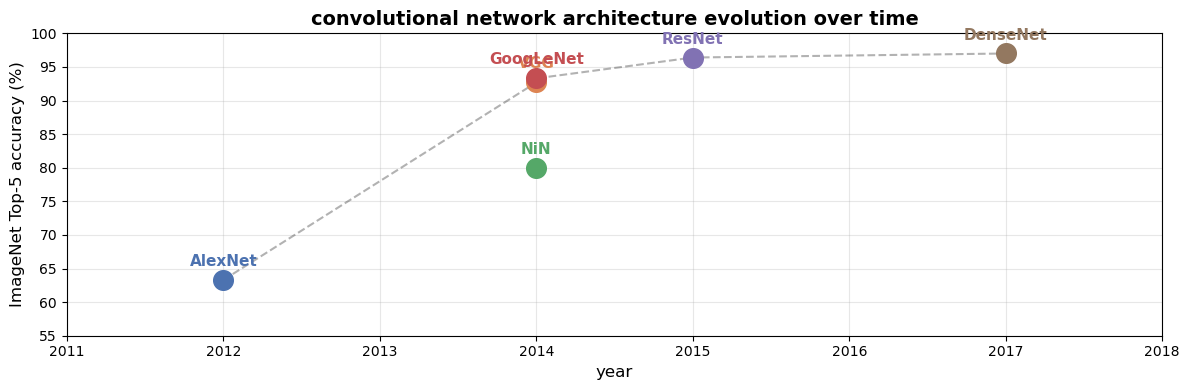

In [8]:
# 架构演进时间线可视化
fig, ax = plt.subplots(figsize=(12, 4))

years    = [2012, 2014, 2014, 2014, 2015, 2017]
names    = ['AlexNet', 'VGG', 'NiN', 'GoogLeNet', 'ResNet', 'DenseNet']
imagenet = [63.3, 92.7, None, 93.3, 96.4, 97.0]  # Top-5 精度（近似）
colors   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3','#937860']

for i, (y, name, acc, c) in enumerate(zip(years, names, imagenet, colors)):
    ax.scatter(y, acc if acc else 80, s=200, color=c, zorder=5)
    ax.annotate(name, (y, acc if acc else 80), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=11, color=c, fontweight='bold')

vals = [(y, a) for y, a in zip(years, imagenet) if a]
ax.plot([v[0] for v in vals], [v[1] for v in vals], 'k--', alpha=0.3)

ax.set_xlabel('year', fontsize=12)
ax.set_ylabel('ImageNet Top-5 accuracy (%)', fontsize=12)
ax.set_title('convolutional network architecture evolution over time', fontsize=14, fontweight='bold')
ax.set_xlim(2011, 2018)
ax.set_ylim(55, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()